## Error

Out of the books different ways of measearing the estimation error of an estimator are supported.

In [1]:
from azcausal.core.parallelize import Joblib
from azcausal.data import CaliforniaProp99
from azcausal.estimators.panel.did import DID

panel = CaliforniaProp99().panel()

# initialize an estimator object, here difference in difference (did)
estimator = DID()

# run the estimator
result = estimator.fit(panel)

print(result.summary(percentage=False))

╭──────────────────────────────────────────────────────────────────────────────╮
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect: -27.35                                                              |
|  Observed: 60.35                                                             |
|  Counter Factual: 87.70                                                      |
├──────────────────────────────────────────────────────────────────────────────┤
|                                  Cumulative                                  |
|  Effect: -328.19                                                             |
|  Observed: 724.20         

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_error_distribution(runs):

    plt.subplots(1, 1, figsize=(12,2))
    x = np.array([result.effect.value for result in runs])
    plt.hist(x, bins=31, color='blue')
    plt.axvline(x.mean(), color='red')

    return x.mean(), x.std()

### Bootstrap

╭──────────────────────────────────────────────────────────────────────────────╮
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -27.35 (±2.7923)                                              |
|  Confidence Interval (95%): [-32.82 , -21.88]                           (-)  |
|  Observed: 60.35                                                             |
|  Counter Factual: 87.70                                                      |
├──────────────────────────────────────────────────────────────────────────────┤
|                                  Cumulative                                  |
|  Effect (±SE): -328.19 (±3

(np.float64(-27.279344861963246), np.float64(2.792262747797979))

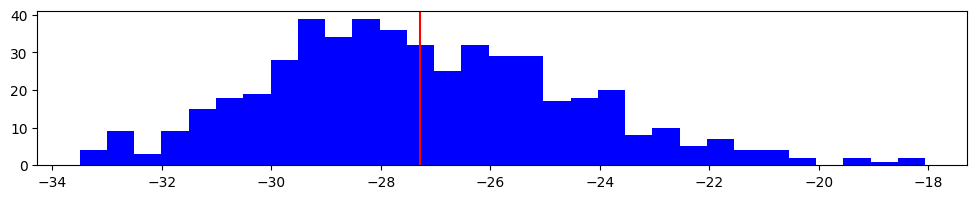

In [3]:
from azcausal.core.error import Bootstrap

method = Bootstrap(n_samples=500)
se, runs = method.run(result)

# print out information about the estimate
print(result.summary(percentage=False))

plot_error_distribution(runs)

### Placebo

╭──────────────────────────────────────────────────────────────────────────────╮
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -27.35 (±18.17)                                               |
|  Confidence Interval (95%): [-62.97 , 8.2711]                         (+/-)  |
|  Observed: 60.35                                                             |
|  Counter Factual: 87.70                                                      |
├──────────────────────────────────────────────────────────────────────────────┤
|                                  Cumulative                                  |
|  Effect (±SE): -328.19 (±2

(np.float64(-0.8596241879653584), np.float64(18.17388989586121))

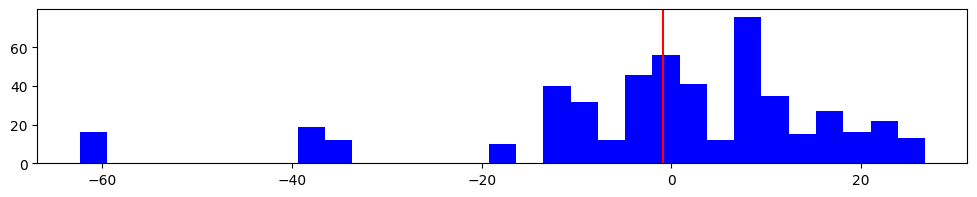

In [4]:
from azcausal.core.error import Placebo

method = Placebo(n_samples=500)
se, runs = method.run(result)

# print out information about the estimate
print(result.summary(percentage=False))

plot_error_distribution(runs)

### JackKnife

╭──────────────────────────────────────────────────────────────────────────────╮
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -27.35 (±2.7671)                                              |
|  Confidence Interval (95%): [-32.77 , -21.93]                           (-)  |
|  Observed: 60.35                                                             |
|  Counter Factual: 87.70                                                      |
├──────────────────────────────────────────────────────────────────────────────┤
|                                  Cumulative                                  |
|  Effect (±SE): -328.19 (±3

(np.float64(-27.34911108361494), np.float64(0.45491579154542355))

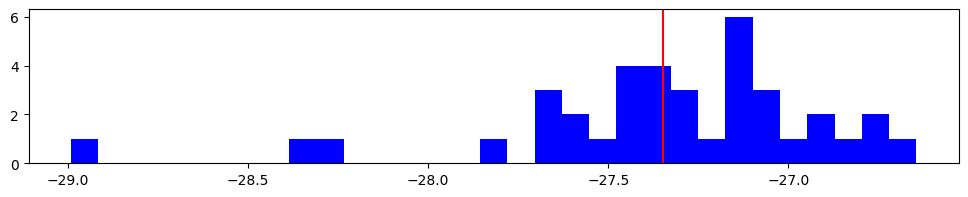

In [5]:
from azcausal.core.error import JackKnife

method = JackKnife()
se, runs = method.run(result)

# print out information about the estimate
print(result.summary(percentage=False))

plot_error_distribution(runs)